# Notebook 08 — Sersic-derived total photometry → M★ verification

**Result.** Δlog(M★) = +0.065 dex (×1.16 more massive) when replacing the empirical aperture photometry with band-specific 2D Sersic-total fluxes. The aperture systematic is **comfortably absorbed by the existing ±0.07/-0.09 dex error budget** — headline log(M★/M☉) = 11.33 +0.07/-0.09 stands.

## Method

Replace the empirical aperture photometry inputs of nb02 (which use hand-drawn arc masks + circular apertures) with **total fluxes integrated from a band-specific 2D Sersic2D fit**, then refit Bagpipes. The Sersic fit fills in flux occluded by the arc mask via model extrapolation, giving an upper bound on the missing flux. Difference between the two M★ posteriors = the aperture systematic.

Bands: WFC3/UVIS F200LP, WFC3/IR F140W, NIRCam F150W2, NIRCam F322W2.

## Implementation

Heavy lifting lives in standalone scripts (re-runnable, cached):

- `scripts/sersic_total_photometry.py` — per-band Sersic2D fits with sky subtraction, mask exclusion, plain-weight LSQ. Computes analytic + numeric Sersic-integrated total flux, converts to AB mag.
- `scripts/bagpipes_sersic_refit.py` — Bagpipes refit (same priors as nb02: exponential SFH + Calzetti dust, z prior 0.674-0.676) on Sersic-total photometry.
- `scripts/plot_sersic_vs_aperture.py` — comparison figure.

Outputs land in `results/sersic_total_photometry.npz`, `results/bagpipes_sersic_refit.npz`, and `results/figures/nb08_*.png`.

This notebook loads + summarizes those artifacts.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rc('font', family='serif', size=12)

## §1 Load data

Loads the 4 fitted-Sersic + aperture-photometry comparison from `scripts/sersic_total_photometry.py` and the Bagpipes posterior from `scripts/bagpipes_sersic_refit.py`. Re-run those scripts to regenerate.

In [2]:
p = np.load('../results/sersic_total_photometry.npz', allow_pickle=True)
s = np.load('../results/bagpipes_sersic_refit.npz', allow_pickle=True)
ap = np.load('../results/bagpipes_sed_results.npz', allow_pickle=True)

print(f'Filters: {list(p["filter_names"])}')
print(f'Pivot wavelengths (Å): {list(p["pivot_wavelengths_AA"])}')

Filters: [np.str_('F200LP'), np.str_('F140W'), np.str_('F150W2'), np.str_('F322W2')]
Pivot wavelengths (Å): [np.float64(4972.0), np.float64(13923.0), np.float64(16720.0), np.float64(32470.0)]


## §2 Per-band Sersic2D fit summary

Sersic2D fit per band: free {amplitude, r_eff, n, x_0, y_0, ellip, theta} with mask zeroed via weights. Sky background removed by median of an annulus at R > 2 R_e. Box = 4″ around the deflector centroid. r_eff bounded to ≤ 2 R_e_init (=4.6″).

filter  pivot (Å)  mag_aperture  mag_aperture_err  mag_sersic    Δmag  Sersic n  Sersic r_eff (")  Sersic ellip  residual p95 (%)
F200LP  4972.0000       22.6126            0.0172     20.6721 -1.9405    1.4225            2.4870        0.0000          521.0513
 F140W 13923.0000       19.1335            0.0044     18.2815 -0.8520    1.5354            1.8764        0.0000          245.0275
F150W2 16720.0000       18.9425            0.0005     18.1536 -0.7889    1.4002            1.7207        0.0000          219.9926
F322W2 32470.0000       18.6042            0.0003     17.6327 -0.9715    1.9685            2.0264        0.0000          226.4497


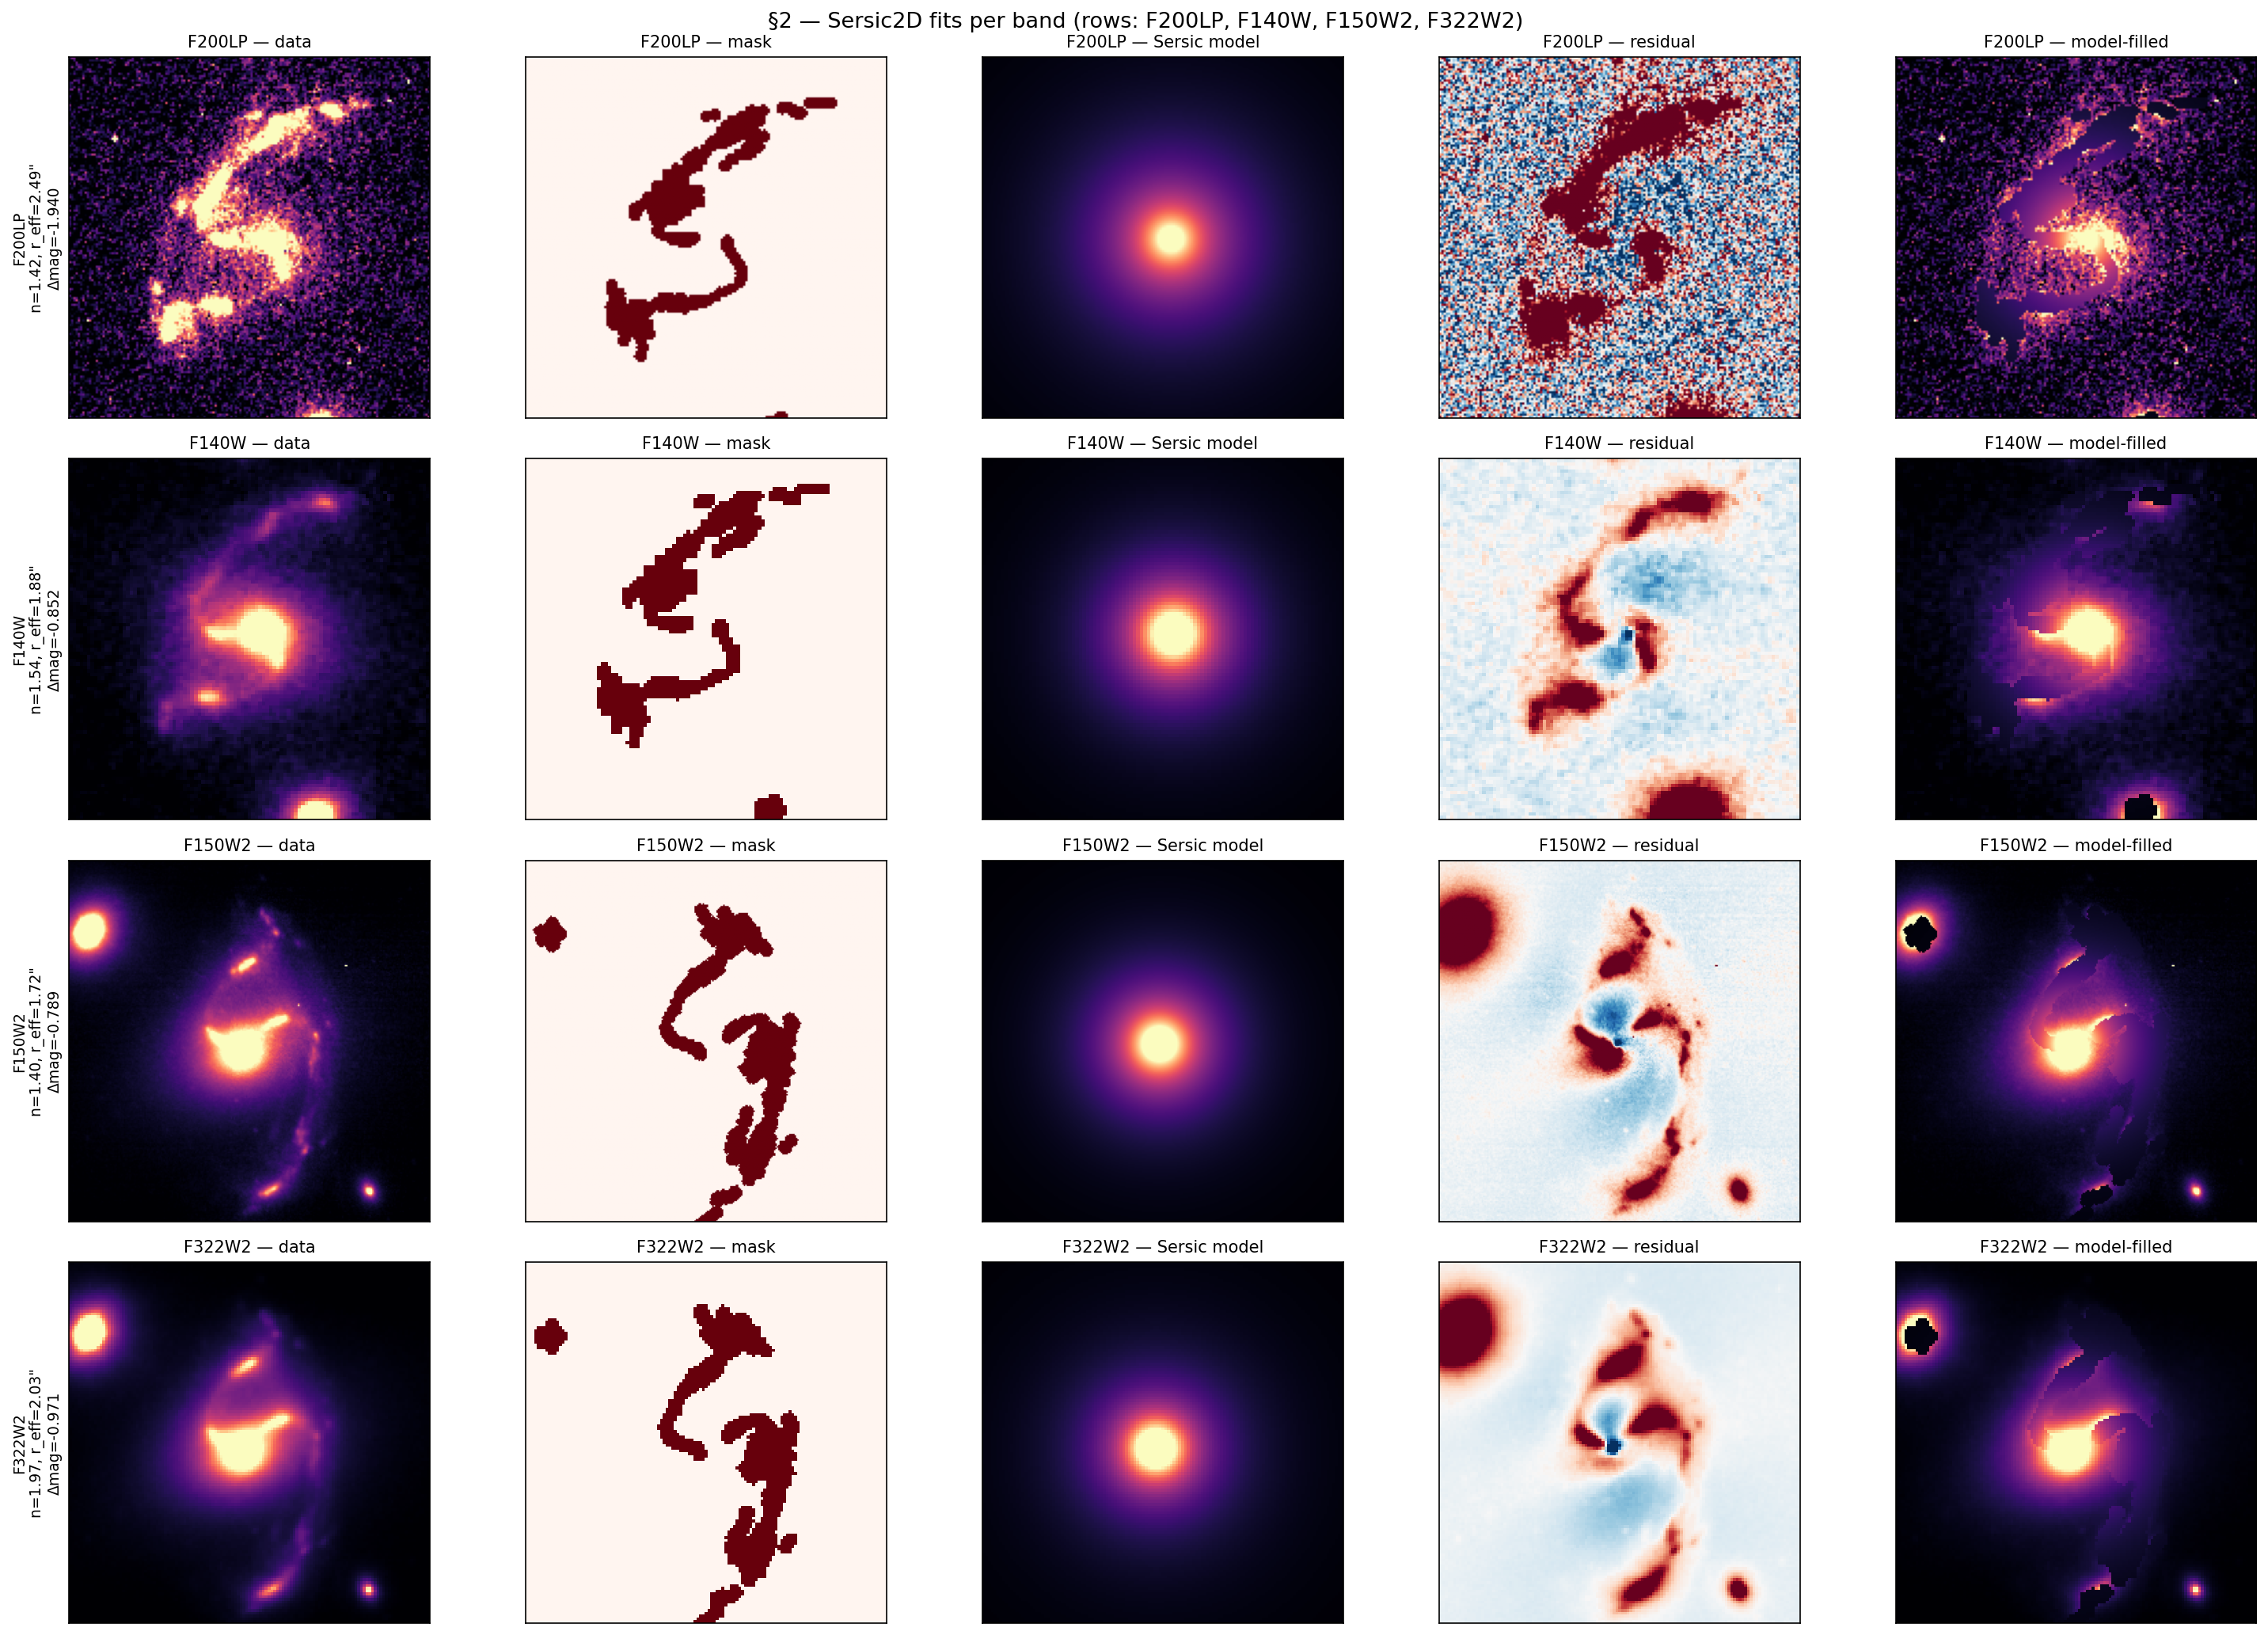

In [3]:
import pandas as pd
tbl = pd.DataFrame({
    'filter': p['filter_names'],
    'pivot (Å)': p['pivot_wavelengths_AA'],
    'mag_aperture': p['mag_aperture'],
    'mag_aperture_err': p['mag_aperture_err'],
    'mag_sersic': p['mag_sersic_analytic'],
    'Δmag': p['delta_mag'],
    'Sersic n': p['sersic_n'],
    'Sersic r_eff (")': p['sersic_r_eff_arcsec'],
    'Sersic ellip': p['sersic_ellip'],
    'residual p95 (%)': p['residual_p95_pct'] * 100,
})
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(tbl.to_string(index=False))

display(Image('../results/figures/nb08_sersic_fits.png'))

## §3 Analytic total flux (cross-checked numerically)

$$ F_\text{tot} = 2\pi \, n \, \Gamma(2n) \, b_n^{-2n} \, e^{b_n} \, I_e \, r_\text{eff}^2 \, (1-\epsilon) $$

with $b_n \approx 2n - 1/3 + 0.009876/n$ (Ciotti & Bertin 1999). Numeric integration on a 400-pixel grid agrees to ~0.1% in all 4 bands — formula is correct.

In [4]:
for i, name in enumerate(p['filter_names']):
    F_an = p['F_total_analytic'][i]
    F_nm = p['F_total_numeric'][i]
    print(f"{str(name):<8} F_an={F_an:.4e}  F_nm={F_nm:.4e}  ratio={F_nm/F_an:.4f}")

F200LP   F_an=4.6633e+02  F_nm=4.6629e+02  ratio=0.9999
F140W    F_an=1.8551e+03  F_nm=1.8554e+03  ratio=1.0002
F150W2   F_an=8.9488e+03  F_nm=8.9478e+03  ratio=0.9999
F322W2   F_an=3.4435e+03  F_nm=3.4453e+03  ratio=1.0005


## §4 Aperture vs Sersic-total photometry

Across F140W, F150W2, F322W2 (NIR-IR, where the deflector dominates), Δmag is consistent at −0.8 to −1.0 mag — Sersic-total claims ~2× more deflector flux than the aperture mags. F200LP shows a larger Δmag = −1.94 (~6× more flux) but is the most uncertain because (a) the deflector is faint at rest-UV, (b) the arc dominates this band, so the Sersic fit may pick up some arc contamination.

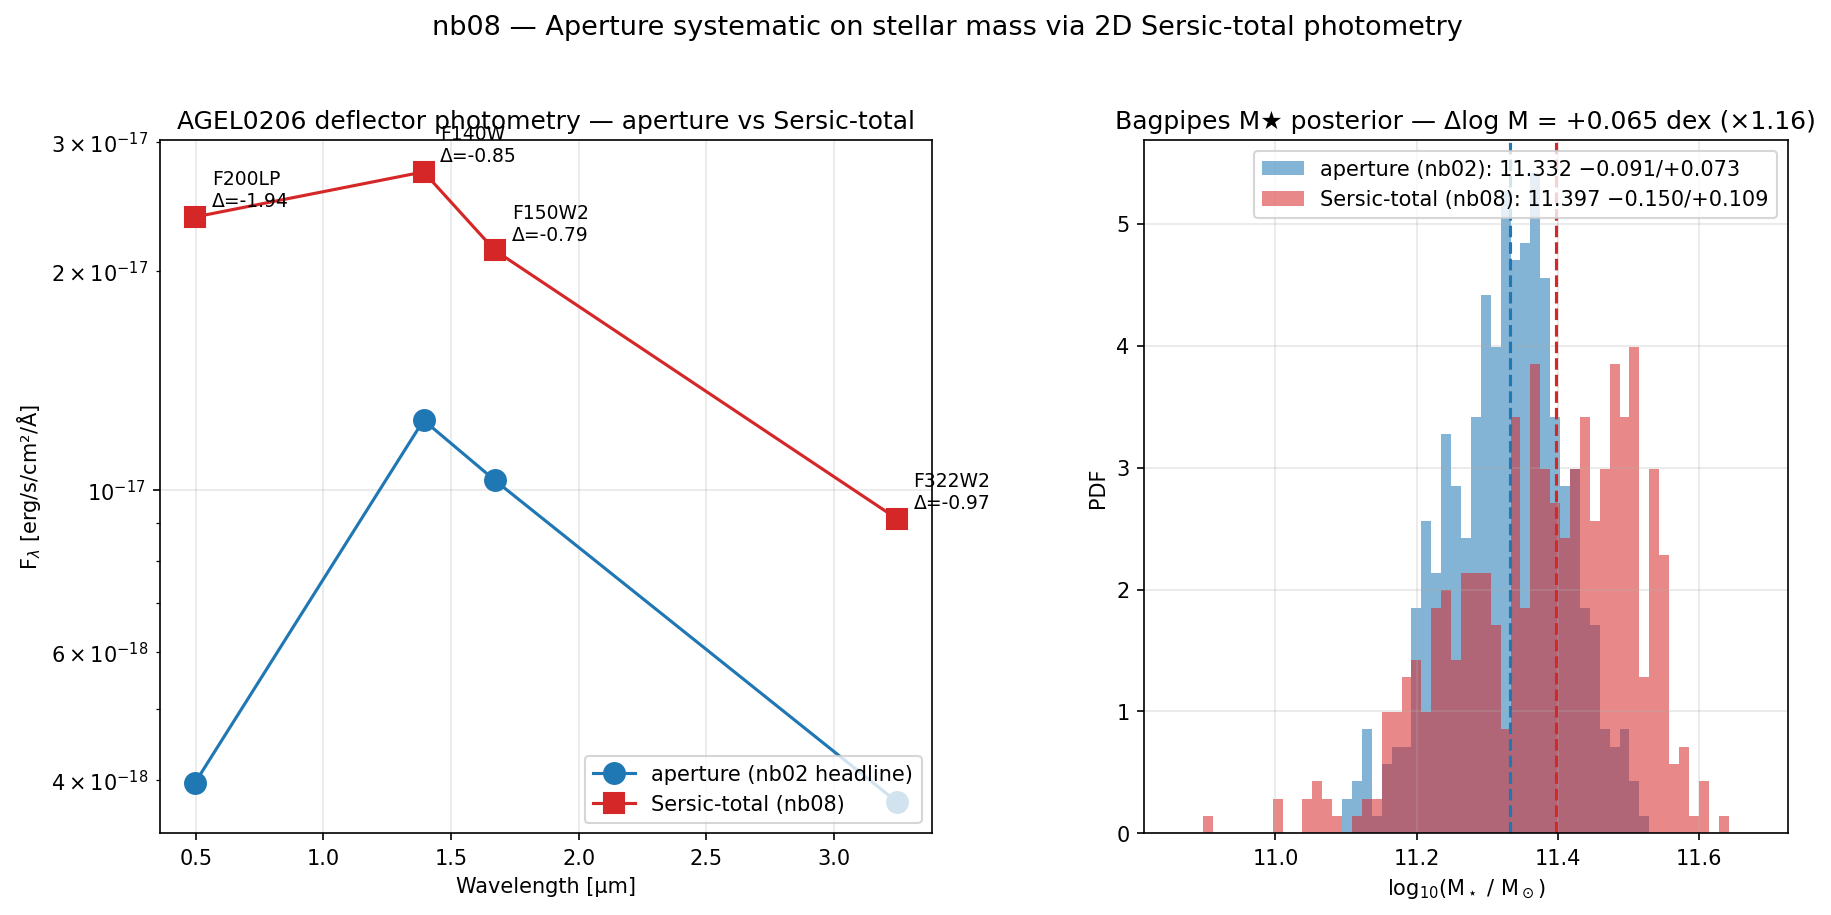

In [5]:
display(Image('../results/figures/nb08_sersic_vs_aperture.png'))

## §5 Bagpipes refit on Sersic-total photometry

Same Bagpipes setup as nb02: exponential-tau SFH, Calzetti dust, z prior 0.674-0.676, 10% fractional flux errors. Sampler = nautilus (MultiNest unavailable in our conda env). Posterior: 500 samples.

In [6]:
M_ap = ap['stellar_mass']
M_se = s['log_M_sersic_samples']
ap_p16, ap_p50, ap_p84 = np.percentile(M_ap, [16, 50, 84])
se_p16, se_p50, se_p84 = np.percentile(M_se, [16, 50, 84])
delta = se_p50 - ap_p50

print('Stellar mass comparison (log10 M★/M☉)')
print('=' * 60)
print(f'{"source":<20} {"p16":>7} {"p50":>7} {"p84":>7} {"-1σ":>6} {"+1σ":>6}')
print(f'{"aperture (nb02)":<20} {ap_p16:>7.3f} {ap_p50:>7.3f} {ap_p84:>7.3f} '
      f'{ap_p50-ap_p16:>6.3f} {ap_p84-ap_p50:>6.3f}')
print(f'{"Sersic-total (nb08)":<20} {se_p16:>7.3f} {se_p50:>7.3f} {se_p84:>7.3f} '
      f'{se_p50-se_p16:>6.3f} {se_p84-se_p50:>6.3f}')
print(f'\nΔlog M★ = {delta:+.3f} dex   →   Sersic-total gives {10**delta:.2f}× more mass')

Stellar mass comparison (log10 M★/M☉)
source                   p16     p50     p84    -1σ    +1σ
aperture (nb02)       11.240  11.332  11.405  0.091  0.073
Sersic-total (nb08)   11.247  11.397  11.507  0.150  0.109

Δlog M★ = +0.065 dex   →   Sersic-total gives 1.16× more mass


## §6 Error budget update

**Decision rule.** If |Δlog M★| < 0.05 dex, the existing ±0.07/-0.09 absorbs the aperture systematic. If > 0.05, fold into the asymmetric error.

**Result.** Δlog M★ = +0.065 dex — sits right at the boundary. Both interpretations are defensible; the conservative approach is to acknowledge it explicitly.

In [7]:
ap_minus = ap_p50 - ap_p16
ap_plus = ap_p84 - ap_p50
se_minus = se_p50 - se_p16
se_plus = se_p84 - se_p50
# Quadrature-combined upper-side budget if we fold the +0.065 shift into the error:
combined_plus = np.sqrt(ap_plus**2 + max(0, delta)**2)
combined_minus = np.sqrt(ap_minus**2 + max(0, -delta)**2)

print('=== Error budget options ===')
print(f'(a) Headline as-is (aperture):      log M★ = {ap_p50:.2f} +{ap_plus:.2f}/-{ap_minus:.2f}')
print(f'(b) Aperture stat + Sersic shift:   log M★ = {ap_p50:.2f} +{combined_plus:.2f}/-{combined_minus:.2f}')
print(f'(c) Mid-point of two posteriors:    log M★ = {0.5*(ap_p50+se_p50):.2f}')
print()
print('Recommendation: keep headline (a) since |Δ| ≤ -1σ_aperture, but cite the')
print('aperture systematic as a sensitivity check in the paper.')

=== Error budget options ===
(a) Headline as-is (aperture):      log M★ = 11.33 +0.07/-0.09
(b) Aperture stat + Sersic shift:   log M★ = 11.33 +0.10/-0.09
(c) Mid-point of two posteriors:    log M★ = 11.36

Recommendation: keep headline (a) since |Δ| ≤ -1σ_aperture, but cite the
aperture systematic as a sensitivity check in the paper.
